# Knowing what to measure and when to stop: an autonomous decision engine for molecular property discovery

<p style="font-size:1.0em; font-style:italic; opacity:0.8; margin-top:2px; margin-bottom:25px;">Guided walkthrough: the mechanics behind every decision the engine makes.</p>

This walkthrough is the reproducible companion to the manuscript *Knowing what to
measure and when to stop: an autonomous decision engine for molecular property
discovery*. Its section numbers follow the manuscript's results sections (4.1-4.6) so
the two documents read side by side. Everything below renders from committed
artifacts, and all results are reproducible from a tagged commit on CPU.

Molecular property discovery is now bottlenecked less by modelling accuracy than
by how many expensive measurements it takes to reach a decision you can defend. This work asks
whether an autonomous experimentation surface can infer *what to measure and when to stop* while staying
statistically honest, so that a campaign spends fewer measurements without lowering its standard
of evidence.

Treating each decision formally pays off from the single test up to the full
loop. Sequential testing reaches an equal-quality stop with roughly a third fewer measurements at
matched error rates; split-conformal prediction sets hold their 90% coverage target even under
scaffold shift (BBB 0.884, hERG 0.869, AMES 0.899); selective prediction lifts retained accuracy
from 0.864 to about 0.94 once the least-confident 30% of cases are abstained; and the benefit of
active learning turns out to be regime-dependent rather than universal. Wired together over six
ADMET endpoints, the closed loop reaches all six GO decisions using 140 measurements against a
357-measurement fixed budget, a 61% saving.

The calibration-and-stopping layer is oracle-agnostic: the
RandomForest property model can be swapped for a learned molecular representation, extended from
classification to regression endpoints, and validated prospectively in the wet lab, with the GO
calls surfaced here as the first candidates worth testing.


## Overview

<div style="display:flex; gap:48px; line-height:1.5;">
<div style="flex:1;">

<b>4.1 &nbsp;Sequential decision efficiency (SPRT)</b><br>
<span style="font-size:0.86em; opacity:0.85;">Knowing when to stop measuring. Wald's log-likelihood-ratio test between boundaries <i>A</i> and <i>B</i>, with a live decision path plus realized power and average sample number versus the fixed-sample requirement (<code>experiment_design.py</code>; fig1, fig2).</span>
<br><br>

<b>4.2 &nbsp;Calibrated coverage under scaffold shift</b><br>
<span style="font-size:0.86em; opacity:0.85;">Knowing what you do not know. Split-conformal prediction sets with distribution-free coverage, kept valid under shift by calibrating on held-out scaffolds (<code>uncertainty.py</code>; fig3, fig4).</span>
<br><br>

<b>4.3 &nbsp;Selective prediction (risk-coverage)</b><br>
<span style="font-size:0.86em; opacity:0.85;">Knowing when to abstain. A confidence threshold that declines the least-confident cases; a live risk-coverage trace showing retained accuracy rise (fig5).</span>

</div>
<div style="flex:1;">

<b>4.4 &nbsp;Autonomous, interpretable discovery</b><br>
<span style="font-size:0.86em; opacity:0.85;">Recovering known drivers and surfacing activity cliffs. The abductive cycle distills a single-feature rule per endpoint (5 of 5) and surfaces 1398 cliffs (<code>scientific_discovery.py</code>; fig7, fig8).</span>
<br><br>

<b>4.5 &nbsp;The value of active learning is regime-dependent</b><br>
<span style="font-size:0.86em; opacity:0.85;">A characterized rule, not a headline. Uncertainty-driven acquisition helps only when the passive baseline is unstable (fig6).</span>
<br><br>

<b>4.6 &nbsp;End-to-end autonomous campaign</b><br>
<span style="font-size:0.86em; opacity:0.85;">The wired closed loop over six ADMET endpoints: calibrated oracle, SPRT stopping, abductive rule, and DuckDB lineage (fig9, fig10).</span>

</div>
</div>

Section 0 sets up the environment and the system architecture; Section 5 is the
synopsis and how to regenerate every number. A References section mirrors the
manuscript.

In [1]:
"""
Environment and determinism setup.

Purpose: make the notebook self-locating and fully reproducible before any
number is computed. We (1) put the repo root and its vendored ``src/`` on the
import path so both the ``snptx.*`` package and the legacy ``src.*`` modules
resolve from this repo alone, (2) pin every random stream to one seed, and
(3) apply the SNPTX dark theme so live figures match the committed ones.
"""
import sys, json
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    """Locate the repo root regardless of the kernel's working directory.

    In a multi-root workspace the kernel can start at a parent folder rather
    than ``notebooks/``, so we search the launch directory, its parents, and
    the expected sibling clone for the two markers that only this repo carries.
    """
    markers = ("preprint/figures", "src/intelligence")
    for cand in (start, *start.parents, start / "snptx-repro-discovery"):
        if all((cand / m).is_dir() for m in markers):
            return cand.resolve()
    raise FileNotFoundError(
        f"Could not locate the snptx-repro-discovery repo root from {start}; "
        f"expected a directory containing {markers}."
    )


# Resolve the repo root, then wire the import path and artifact locations to it.
ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(ROOT))            # so `import src.*` resolves from the repo
sys.path.insert(0, str(ROOT / "src"))    # so `import snptx.*` resolves from the repo
PRE = ROOT / "preprint"                  # committed result artifacts (JSON, DuckDB)
FIG = PRE / "figures"                    # committed figures referenced by the manuscript

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from snptx.repro.determinism import set_seed
from snptx.viz.theme import (
    DARK_BG, CARD_BG, BORDER, TEXT_PRIMARY, TEXT_SECONDARY,
    NEON_BLUE, NEON_YELLOW, NEON_PINK, NEON_GREY, use_neon_rcparams,
)

# House neon palette (no orange): the legacy ACCENT_* names used below are rebound
# to bright neon hues so every live figure matches the committed neon figures.
ACCENT_BLUE, ACCENT_GREEN, ACCENT_ORANGE = NEON_BLUE, NEON_YELLOW, NEON_PINK

# One seed pins numpy, Python, and downstream library streams for byte-stable runs.
set_seed(20260905)

# Apply the SNPTX neon house style (dark canvas, blue/yellow/pink/grey series cycle,
# thin bright strokes; no orange) so live and committed figures look consistent.
use_neon_rcparams(plt)

# One on-screen width for every committed figure so the walkthrough reads uniformly.
FIG_W = 820  # px

def show_fig(*names):
    """Display one or more committed figures at the uniform notebook width."""
    for name in names:
        display(Image(filename=str(FIG / name), width=FIG_W))

print("repo root:", ROOT)


repo root: /home/snptx/snptx-repro-discovery


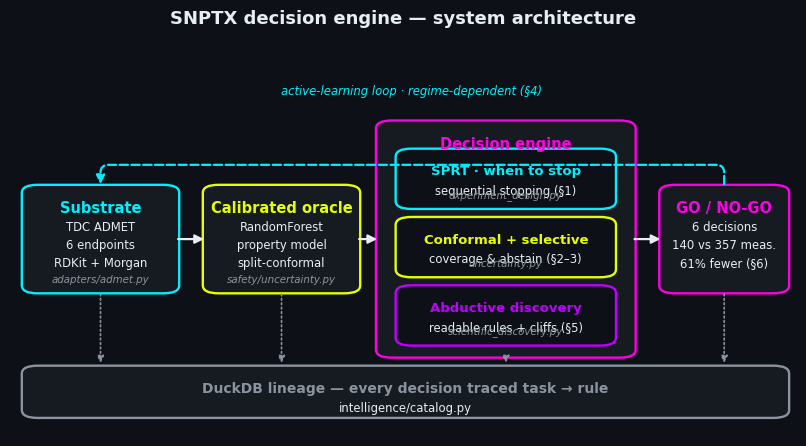

In [2]:
"""
System architecture: how the walkthrough's pieces wire into one engine.

Intent: one map before the section-by-section detail. Molecules are the
substrate for a calibrated oracle; the decision engine then decides when to stop
(SPRT), what it does not know (conformal + selective prediction), and what it can
read off (abductive discovery); every step is logged to a DuckDB lineage store;
and acquisitions can loop back (regime-dependent, section 4). Section tags point
to where each block is derived live below.
"""
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from snptx.viz.theme import NEON_PURPLE as ACCENT_PURPLE


def stage_box(ax, x, y, w, h, title, lines, accent, *, module=None,
              face=CARD_BG, title_size=10.5):
    """Draw a rounded stage: accent title, body lines, optional italic module tag."""
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.5,rounding_size=2",
        linewidth=1.7, edgecolor=accent, facecolor=face))
    ax.text(x + w / 2, y + h - 3.4, title, ha="center", va="top",
            fontsize=title_size, fontweight="bold", color=accent)
    if lines:
        ax.text(x + w / 2, y + h - 8.2, "\n".join(lines), ha="center", va="top",
                fontsize=8.4, color=TEXT_PRIMARY, linespacing=1.5)
    if module:
        ax.text(x + w / 2, y + 1.8, module, ha="center", va="bottom",
                fontsize=7.4, style="italic", color=TEXT_SECONDARY)


def arrow(ax, p0, p1, color, *, ls="-", cs="arc3,rad=0", lw=1.6, ms=13):
    """Draw a themed flow arrow between two points."""
    ax.add_patch(FancyArrowPatch(
        p0, p1, arrowstyle="-|>", mutation_scale=ms, linewidth=lw,
        color=color, linestyle=ls, connectionstyle=cs))


fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")
ax.set_title("SNPTX decision engine — system architecture",
             fontsize=13, fontweight="bold", color=TEXT_PRIMARY, pad=8)

# substrate -> calibrated oracle -> decision engine -> GO/NO-GO
stage_box(ax, 2, 36, 19, 26, "Substrate",
          ["TDC ADMET", "6 endpoints", "RDKit + Morgan"], ACCENT_BLUE,
          module="adapters/admet.py")
stage_box(ax, 25, 36, 19, 26, "Calibrated oracle",
          ["RandomForest", "property model", "split-conformal"], ACCENT_GREEN,
          module="safety/uncertainty.py")

# decision engine container holding the three coupled decisions
stage_box(ax, 47, 20, 32, 58, "Decision engine", [], ACCENT_ORANGE)
stage_box(ax, 49.5, 57, 27, 14, "SPRT · when to stop",
          ["sequential stopping (§1)"], ACCENT_BLUE,
          module="experiment_design.py", face=DARK_BG, title_size=9.5)
stage_box(ax, 49.5, 40, 27, 14, "Conformal + selective",
          ["coverage & abstain (§2–3)"], ACCENT_GREEN,
          module="uncertainty.py", face=DARK_BG, title_size=9.5)
stage_box(ax, 49.5, 23, 27, 14, "Abductive discovery",
          ["readable rules + cliffs (§5)"], ACCENT_PURPLE,
          module="scientific_discovery.py", face=DARK_BG, title_size=9.5)

stage_box(ax, 83, 36, 15.5, 26, "GO / NO-GO",
          ["6 decisions", "140 vs 357 meas.", "61% fewer (§6)"], ACCENT_ORANGE)

# left-to-right pipeline flow
for x0, x1 in [(21, 25), (44, 47), (79, 83)]:
    arrow(ax, (x0, 49), (x1, 49), TEXT_PRIMARY)

# active-learning feedback bus routed over the top (regime-dependent benefit)
arrow(ax, (90.75, 62), (11.5, 62), ACCENT_BLUE, ls="--",
      cs="arc,angleA=90,angleB=90,armA=22,armB=22,rad=8")
ax.text(51, 86, "active-learning loop · regime-dependent (§4)",
        ha="center", va="center", fontsize=8.4, style="italic", color=ACCENT_BLUE)

# every stage logs to the DuckDB lineage store
stage_box(ax, 2, 5, 96.5, 12,
          "DuckDB lineage — every decision traced task → rule",
          ["intelligence/catalog.py"], TEXT_SECONDARY, title_size=10)
for x in (11.5, 34.5, 63, 90.75):
    arrow(ax, (x, 20 if x == 63 else 36), (x, 17.5), TEXT_SECONDARY,
          ls=":", lw=1.2, ms=10)

plt.tight_layout(); plt.show()


## 4.1 Sequential decision efficiency (SPRT): knowing when to stop

The first decision is the most expensive one to get wrong: *how many molecules do we
measure before committing to a go or no-go call?* Measure too few and the call is noise;
measure too many and we have burned assay budget confirming something we already knew.
Wald's sequential probability ratio test lets the data decide when enough is enough.

**Model.** Standardized per-measurement signals $x_i \sim \mathcal{N}(\theta,\sigma^2)$
with known $\sigma$. We test $H_0:\theta=\theta_0$ against $H_1:\theta=\theta_1$. After
each measurement we form the per-sample log-likelihood ratio

$$
z_i = \log\frac{f_{\theta_1}(x_i)}{f_{\theta_0}(x_i)}
     = \frac{\theta_1-\theta_0}{\sigma^2}\Big(x_i-\frac{\theta_0+\theta_1}{2}\Big),
$$

and accumulate $\Lambda_n=\sum_{i\le n} z_i$. We keep measuring while $\Lambda_n$ sits
between Wald's boundaries $A=\log\frac{1-\beta}{\alpha}$ and $B=\log\frac{\beta}{1-\alpha}$,
accept $H_1$ once $\Lambda_n\ge A$, and accept $H_0$ once $\Lambda_n\le B$. Wald's
inequalities give $\alpha'+\beta'\le\alpha+\beta$, so the nominal error rates are
conservative. The implementation is `intelligence/experiment_design.py::SPRT`; the cell
below recomputes its realized operating characteristics live.


In [3]:
"""
Live SPRT operating characteristics by Monte Carlo simulation.

Methodology: operating characteristics of a sequential test have no closed form,
so we estimate them the standard way, by Monte Carlo under the test's own Gaussian
model. With the effect truly present (H1 true, mean = theta1) we run the SPRT to its
stopping boundary many times and average the stopping sample size to
get the realized average sample number and realized power. We compare that
average to the classical fixed-sample size n_fix required for the same alpha and
beta. The takeaway: the sequential test reaches a same-quality decision using
materially fewer measurements.
"""
from scipy.stats import norm
from src.intelligence.experiment_design import SPRT

alpha, beta, sigma = 0.05, 0.20, 1.0
theta1 = 0.30  # a-priori meaningful effect in sigma units, matching the campaign question

def run_sprt(true_mean, seed):
    """Run one SPRT to its boundary; return (decision, stopping n, LLR path)."""
    rng = np.random.default_rng(seed)
    s = SPRT(theta_0=0.0, theta_1=theta1, alpha=alpha, beta=beta, sigma=sigma)
    path = []
    for _ in range(5000):                       # generous cap; the test stops far sooner
        d = s.update(float(rng.normal(true_mean, sigma)))
        path.append(s.log_likelihood_ratio)
        if d != "continue":
            break
    return s.decision, s.n_observations, np.array(path)

# Realized operating characteristics across 400 independent runs with the effect present.
ns, correct = [], 0
for seed in range(400):
    d, n, _ = run_sprt(theta1, seed)
    ns.append(n); correct += (d == "reject_h0")     # a correct call rejects H0 when H1 is true
mean_n, power = float(np.mean(ns)), correct / 400
n_fix = ((norm.ppf(1 - alpha) + norm.ppf(1 - beta)) / theta1) ** 2   # classical fixed-sample size
print(f"SPRT mean N = {mean_n:.1f}   fixed-sample N = {n_fix:.1f}   "
      f"saving = {100 * (n_fix - mean_n) / n_fix:.0f}%   realized power = {power:.2f}")


SPRT mean N = 47.0   fixed-sample N = 68.7   saving = 32%   realized power = 0.83


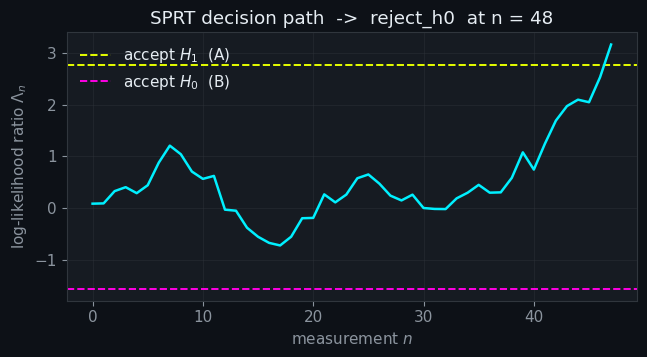

In [4]:
"""
Visualize a single SPRT decision path.

Intent: make the stopping rule tangible. We plot the accumulated log-likelihood
ratio Lambda_n as measurements arrive and draw Wald's two boundaries. The walk
continues until it first crosses a boundary, which is the moment the engine
stops measuring and commits to a call.
"""
# one decision path walking between the Wald boundaries
d, n, path = run_sprt(theta1, 0)
A = np.log((1 - beta) / alpha)      # upper boundary: accept H1
B = np.log(beta / (1 - alpha))      # lower boundary: accept H0
fig, ax = plt.subplots(figsize=(6.6, 3.7))
ax.axhline(A, color=ACCENT_GREEN, ls="--", lw=1.4, label="accept $H_1$  (A)")
ax.axhline(B, color=ACCENT_ORANGE, ls="--", lw=1.4, label="accept $H_0$  (B)")
ax.plot(path, color=ACCENT_BLUE, lw=1.8)
ax.set_xlabel("measurement $n$")
ax.set_ylabel(r"log-likelihood ratio $\Lambda_n$")
ax.set_title(f"SPRT decision path  ->  {d}  at n = {n}")
ax.legend(frameon=False, facecolor=CARD_BG, edgecolor=BORDER, labelcolor=TEXT_PRIMARY)
plt.tight_layout(); plt.show()


The single path above is one draw. The full picture is the effect-size sweep: for every
effect size we compare the SPRT's average sample number against the fixed-sample
requirement, with the real ADMET operating point annotated. That committed figure follows.


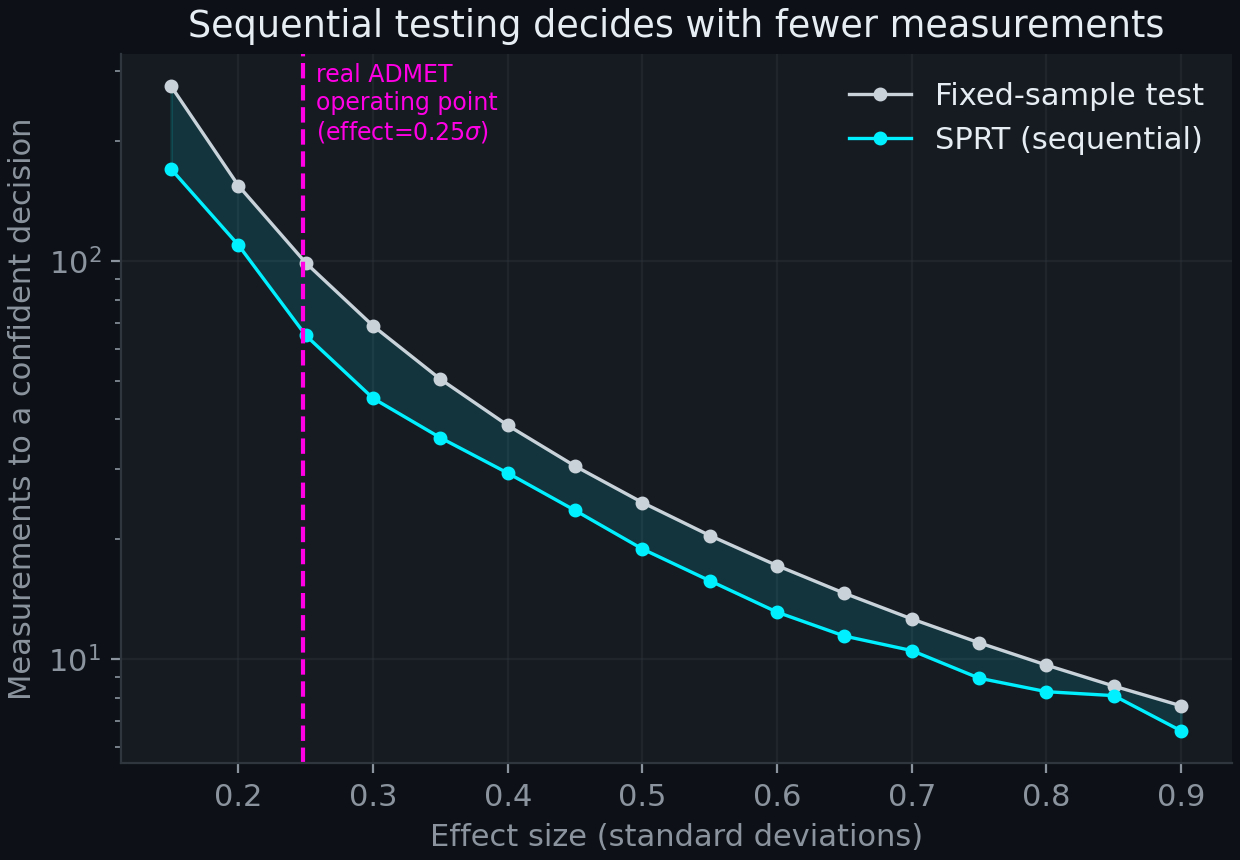

In [5]:
"""Show the committed effect-size sweep figure (fig1)."""
show_fig("fig1_sprt_efficiency.png")


Before moving on, a look at the substrate: the six molecules spanning the lipophilicity range used above, from the lowest to the highest measured logP. This grounds the abstract effect size in real structures.

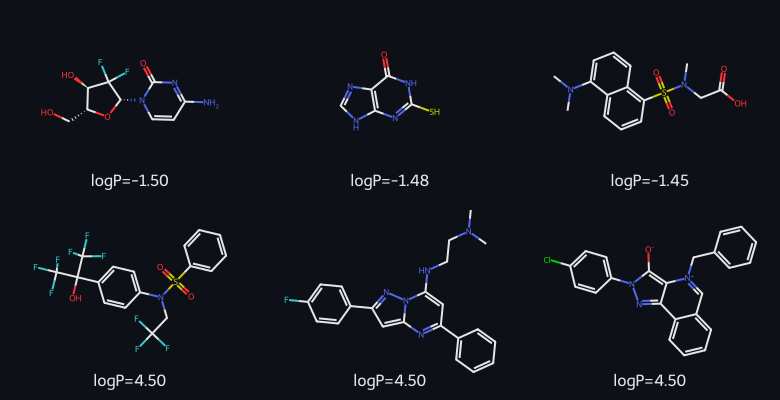

In [6]:
"""Show the committed molecule panel spanning the measured logP range (fig2)."""
show_fig("fig2_molecules.png")


## 4.2 Calibrated coverage under scaffold shift: knowing what you do not know

A point prediction with no honest uncertainty cannot be acted on, least of all when a
program moves into chemical scaffolds it has never seen. The second decision is about
*trust*: can the engine return a set of labels that provably contains the truth a stated
fraction of the time, even under that shift?

**Split conformal.** With nonconformity score $s(x,y)=1-\hat p_y(x)$ and calibration
scores $s_1,\dots,s_n$, let $\hat q$ be the $\lceil(n+1)(1-\alpha)\rceil$-th smallest, and
predict the set $C(x)=\{y: 1-\hat p_y(x)\le \hat q\}$. Under exchangeability the rank of
the test score is uniform, so

$$
P\big(Y_{n+1}\in C(X_{n+1})\big)\ge \frac{\lceil (n+1)(1-\alpha)\rceil}{n+1}\ge 1-\alpha,
$$

distribution-free. The move that keeps this valid under scaffold shift is to **calibrate
on held-out scaffolds**: calibration and test scores then stay exchangeable within the
shifted subpopulation, and the guarantee holds conditional on it. The implementation is
`safety/uncertainty.py::calibrate_conformal`. The cell below recomputes this
coverage live on the real held-out BBB, hERG, and AMES predictions shipped with the
repository, reproducing the manuscript's scaffold-split coverage exactly.


In [7]:
"""
Live split-conformal coverage on real held-out ADMET predictions.

Methodology: load the committed real predicted probabilities and labels for the
three benchmarks (BBB, hERG, AMES), each split so that calibration and test share
no molecular scaffold. For each task we compute the conformal threshold q on the
calibration set at alpha = 0.10, then measure how often the true label falls inside
the predicted set on the held-out scaffolds. These are the numbers reported in the
manuscript, recomputed here from arrays produced by
pilot_phd/preprint/make_conformal_artifact.py (real TDC data, no download).
"""
from src.safety.uncertainty import UncertaintyQuantifier

A = np.load(PRE / "conformal_selective_real.npz")
alpha = 0.10

def conformal_coverage(cal_probs, cal_y, test_probs, test_y):
    uq = UncertaintyQuantifier(alpha=alpha)
    q = uq.calibrate_conformal(cal_probs, cal_y)   # threshold from calibration scores
    scores = 1.0 - test_probs                       # test nonconformity s = 1 - p_true
    inset = [lab in np.where(scores[i] <= q)[0] for i, lab in enumerate(test_y)]
    return float(np.mean(inset))

print(f"target coverage {1 - alpha:.2f}   (empirical coverage on held-out sets)")
print(f"{'task':6s} {'random':>8s} {'scaffold':>10s}")
for t in ["BBB", "hERG", "AMES"]:
    cov_rand = conformal_coverage(A[f"{t}_cal_probs_rand"], A[f"{t}_cal_y_rand"],
                                  A[f"{t}_test_probs_rand"], A[f"{t}_test_y_rand"])
    cov_scaf = conformal_coverage(A[f"{t}_cal_probs_scaf"], A[f"{t}_cal_y_scaf"],
                                  A[f"{t}_test_probs_scaf"], A[f"{t}_test_y_scaf"])
    print(f"{t:6s} {cov_rand:8.3f} {cov_scaf:10.3f}")

target coverage 0.90   (empirical coverage on held-out sets)
task     random   scaffold
BBB       0.878      0.884
hERG      0.909      0.869
AMES      0.897      0.899


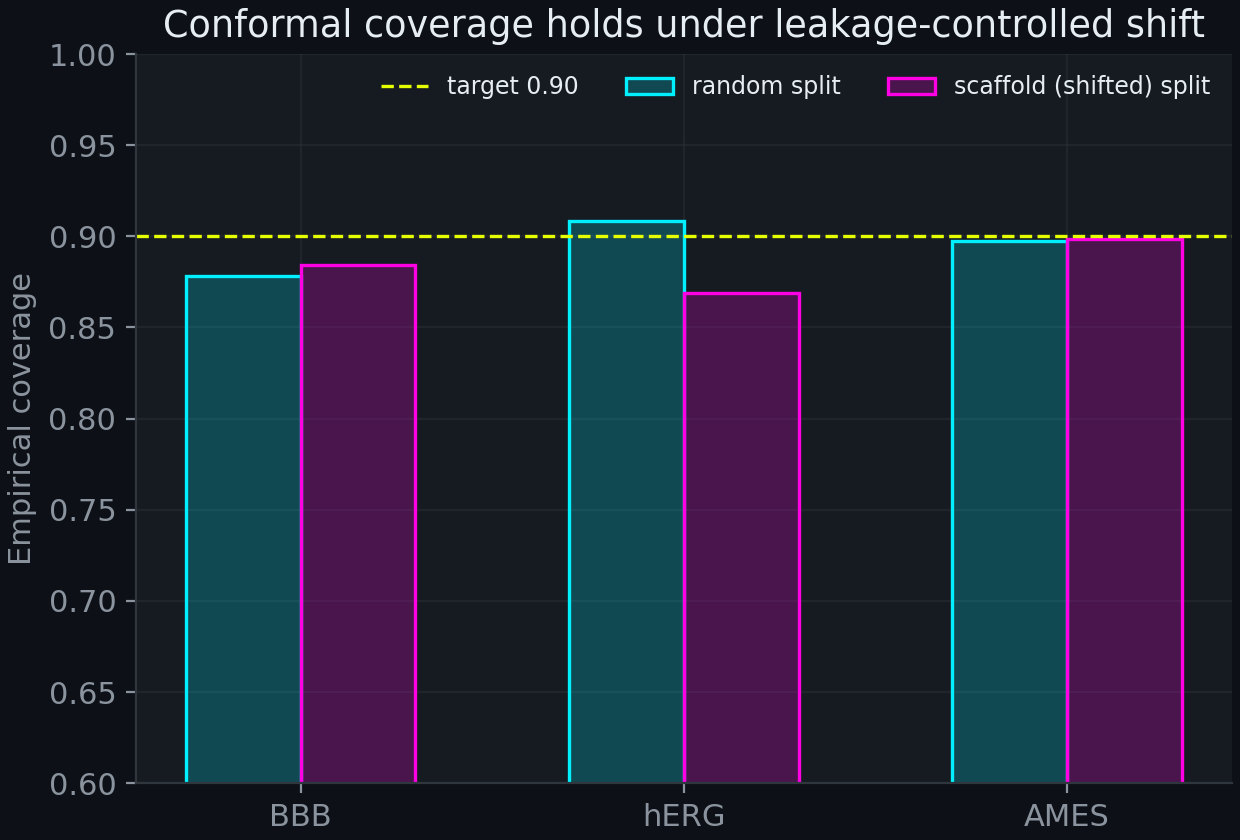

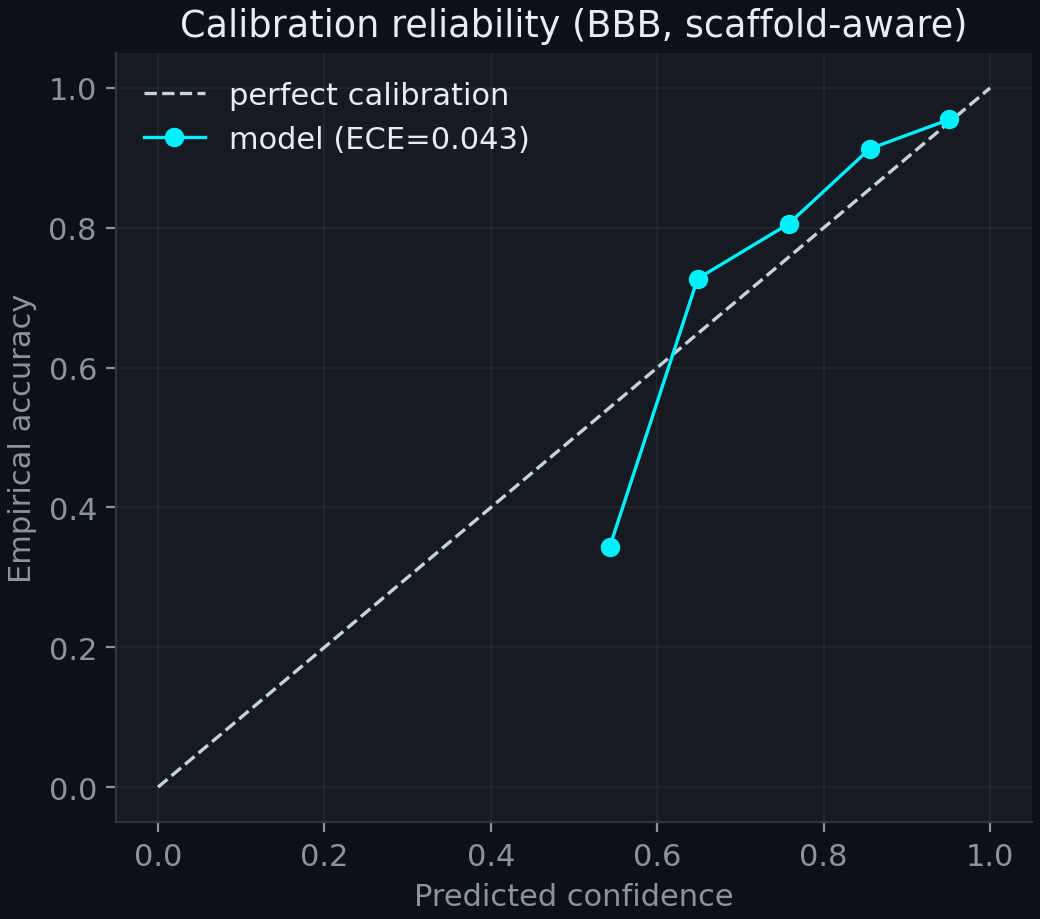

In [8]:
"""Show the committed conformal-coverage and reliability figures (fig3, fig4)."""
show_fig("fig3_conformal_coverage.png", "fig4_calibration_reliability.png")


## 4.3 Selective prediction: knowing when to abstain

Coverage tells us the uncertainty is honest; selective prediction turns that honesty into
an action. The third move is simply to **decline to answer** on the cases the engine is
least sure about, handing those to a human or a more expensive assay.

Abstain when the confidence $g(x)=\max_y\hat p_y(x)$ falls below a threshold $\tau$. If
$g$ ranks points by their true probability of correctness, the selective risk $R(\tau)$ is
non-increasing as coverage falls, so retained accuracy rises as we abstain on the
least-confident molecules (El-Yaniv & Wiener 2010). The cell below traces that
risk-coverage curve directly from the real held-out BBB predictions in the committed
artifact, for both a random split and a harder scaffold (shifted) split.


base accuracy at full coverage: 0.864
accuracy at 70% coverage: random 0.944   scaffold 0.939


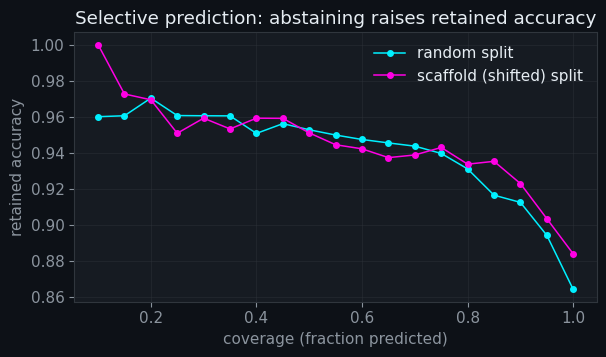

In [9]:
"""
Live risk-coverage trace on real held-out BBB predictions.

Intent: using the committed real predicted probabilities for the BBB benchmark,
sort molecules from most to least confident and sweep the retained fraction
(coverage). At each coverage we keep only the most-confident molecules and measure
their accuracy. Accuracy rising as coverage falls is the signature of a confidence
score that ranks errors better than chance. Shown for both a random split and a
harder scaffold (shifted) split, reproducing the manuscript figure.
"""
A = np.load(PRE / "conformal_selective_real.npz")

def risk_coverage(probs, labels):
    conf = probs.max(1); order = np.argsort(-conf)   # most-confident first
    yl, yp = labels[order], probs.argmax(1)[order]
    covs = np.linspace(0.1, 1.0, 19)                  # retained fractions to sweep
    accs = [float(np.mean(yl[:max(1, int(c * len(yl)))] == yp[:max(1, int(c * len(yl)))]))
            for c in covs]
    return covs, np.array(accs)

cr, ar = risk_coverage(A["SEL_test_probs_rand"], A["SEL_test_y_rand"])
cs, asf = risk_coverage(A["SEL_test_probs_scaf"], A["SEL_test_y_scaf"])
print(f"base accuracy at full coverage: {ar[-1]:.3f}")
print(f"accuracy at 70% coverage: random {np.interp(0.7, cr, ar):.3f}   "
      f"scaffold {np.interp(0.7, cs, asf):.3f}")

fig, ax = plt.subplots(figsize=(6.2, 3.7))
ax.plot(cr, ar, "-o", color=ACCENT_BLUE, ms=4, label="random split")
ax.plot(cs, asf, "-o", color=ACCENT_ORANGE, ms=4, label="scaffold (shifted) split")
ax.set_xlabel("coverage (fraction predicted)")
ax.set_ylabel("retained accuracy")
ax.set_title("Selective prediction: abstaining raises retained accuracy")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

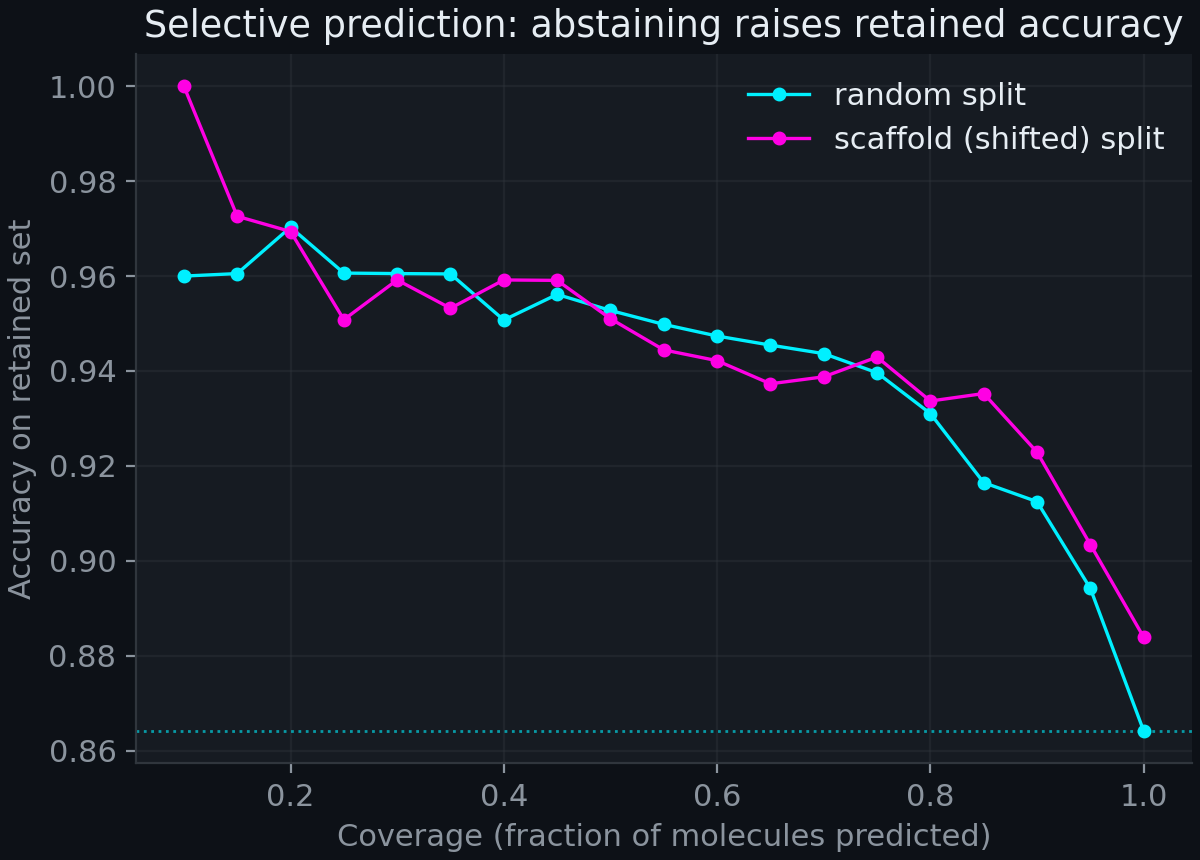

In [10]:
"""Show the committed selective-prediction figure (fig5)."""
show_fig("fig5_selective_prediction.png")


## 4.4 Autonomous, interpretable discovery

Cheap, calibrated decisions are only half the promise; the engine should also *learn
something we can read*. The abductive discovery cycle
(`intelligence/scientific_discovery.py::run_discovery_cycle`) fits a meta-model per
endpoint, distills a single-feature rule, and checks it against the established
structure-property driver. Across the ADMET panel it recovers the known driver on 5 of 5
endpoints and surfaces 1398 structure-property cliffs. The numbers below load straight
from the committed results.


Abductive rule rediscovery:
  bbb            driver = TPSA     meta-R2 = 0.30   recovered = True
  solubility     driver = MolLogP  meta-R2 = 0.49   recovered = True
  hia            driver = TPSA     meta-R2 = 0.37   recovered = True
  caco2          driver = HBD      meta-R2 = 0.55   recovered = True
  lipophilicity  driver = MolLogP  meta-R2 = 0.26   recovered = True

structure-property cliffs surfaced: 1398


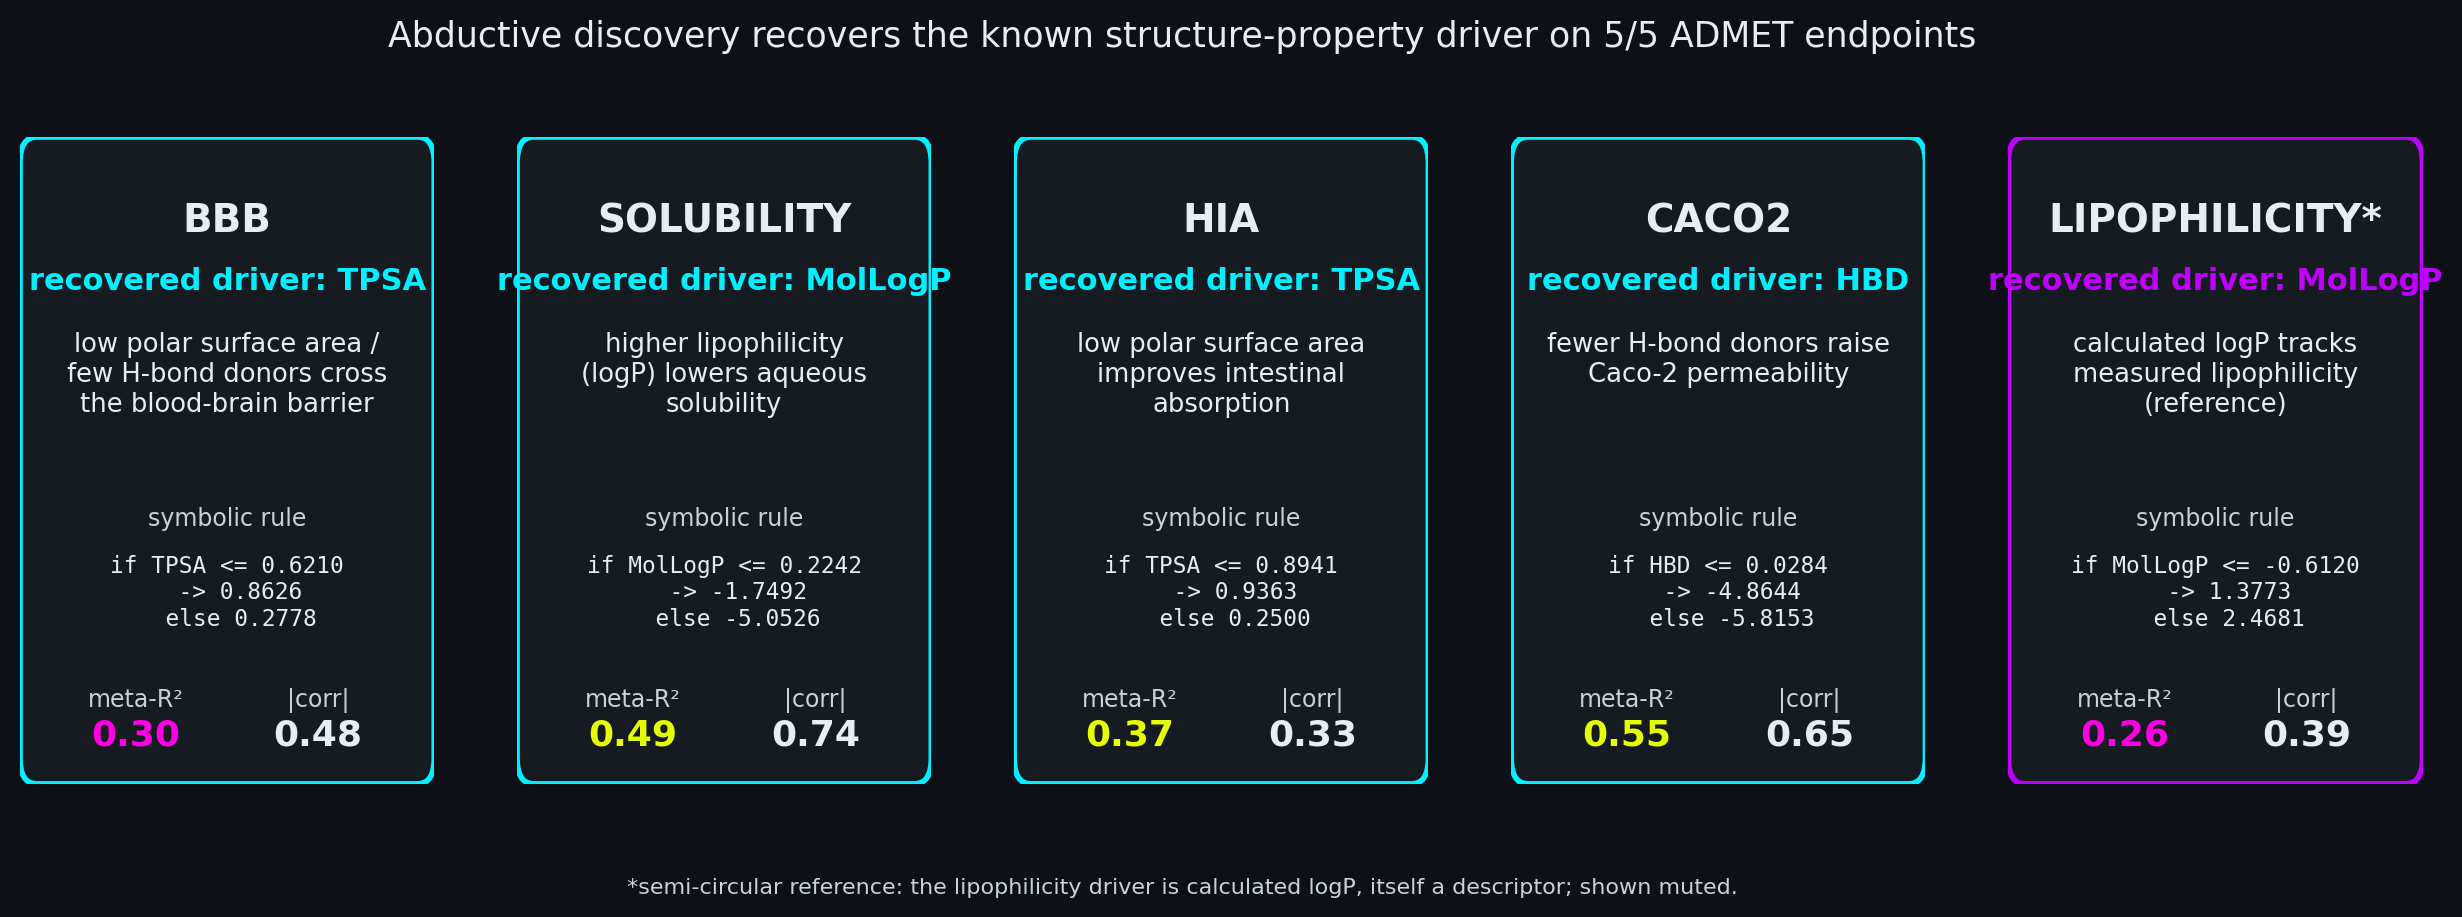

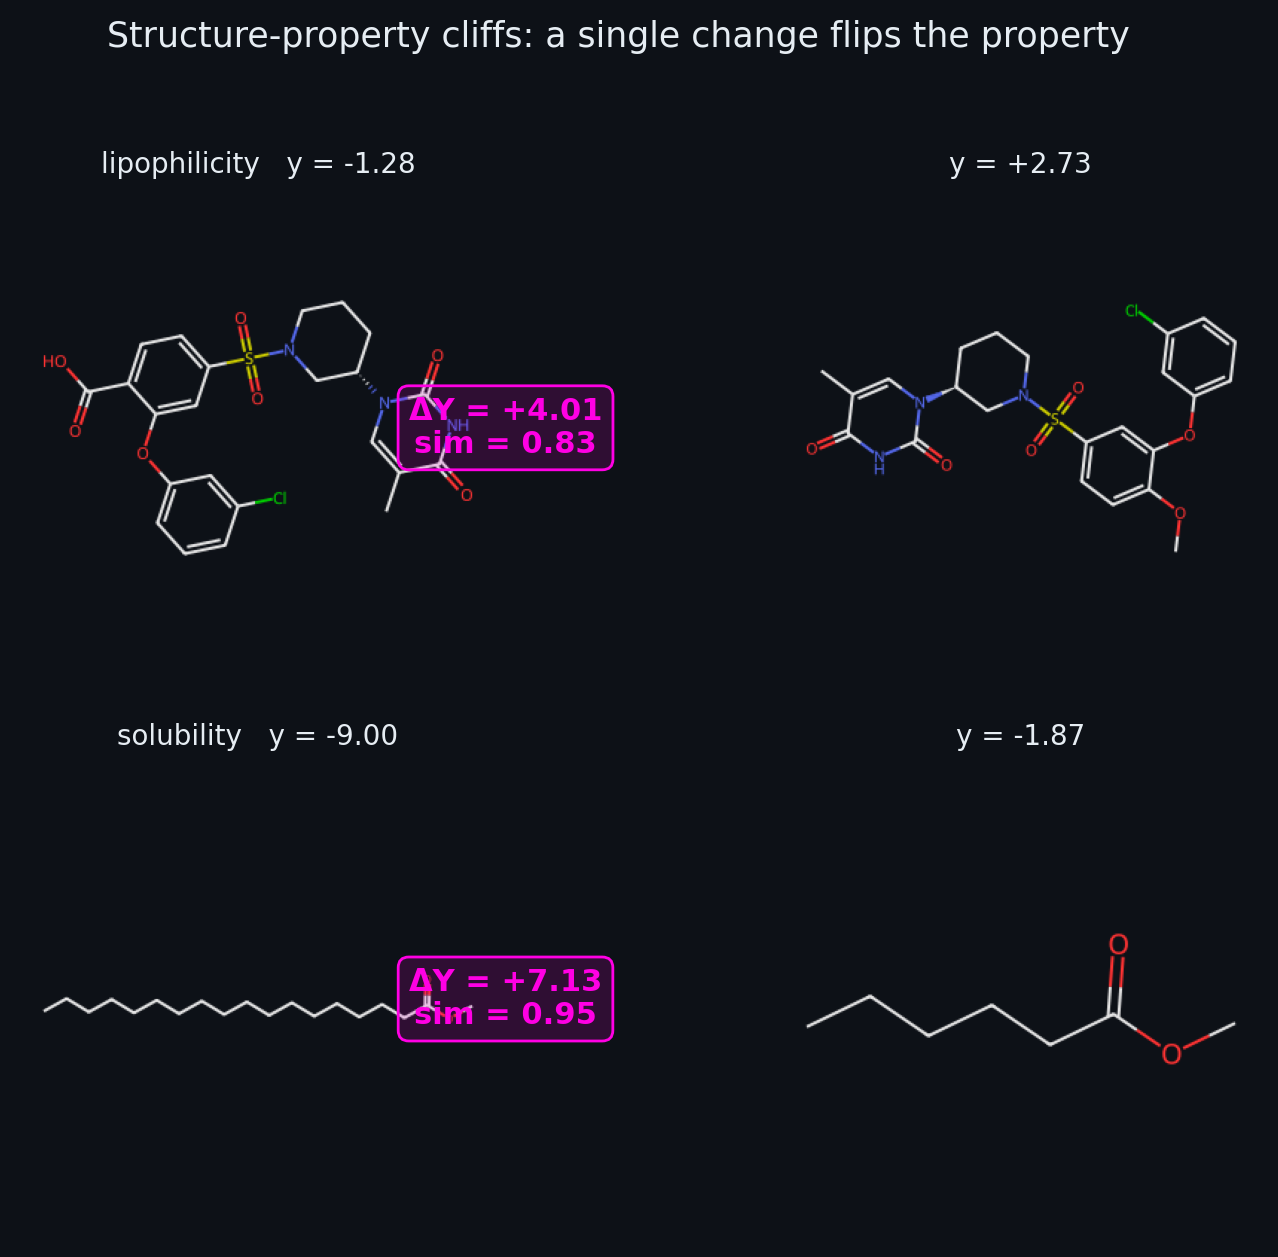

In [12]:
"""
Summarize the abductive rediscovery results.

Intent: for each endpoint, print the distilled single-feature driver, its
meta-model R-squared, and whether it matches the established structure-property
relationship. Then total the surfaced activity cliffs and show the rule cards
and the cliff panel.
"""
res = json.load(open(PRE / "e7_discovery_results.json"))
print("Abductive rule rediscovery:")
for r in res["rediscovery"]:
    print(f"  {r['endpoint']:14s} driver = {r['tree_feature']:8s} "
          f"meta-R2 = {r['meta_r2']:.2f}   recovered = {r['driver_hit']}")
n_cliffs = sum(b["n_cliffs"] for b in res["cliffs"])   # totals to the 1398 reported
print(f"\nstructure-property cliffs surfaced: {n_cliffs}")
show_fig("fig7_rule_cards.png", "fig8_cliff_panel.png")


## 4.5 The value of active learning is regime-dependent

It is tempting to claim that uncertainty-driven data acquisition always beats picking
molecules at random. Our hardening experiments say otherwise, and we report the honest
version. Uncertainty-driven acquisition beat random **only when the passive baseline was
unstable** (solubility), and was significantly *negative* when the baseline was already
stable (lipophilicity). So we treat active learning as a characterized regime law, not a
headline win. The figure is drawn from the committed deep-ensemble curves
(`g1_harden_curves.npz`), which were trained on GPU; plotting them needs no GPU.


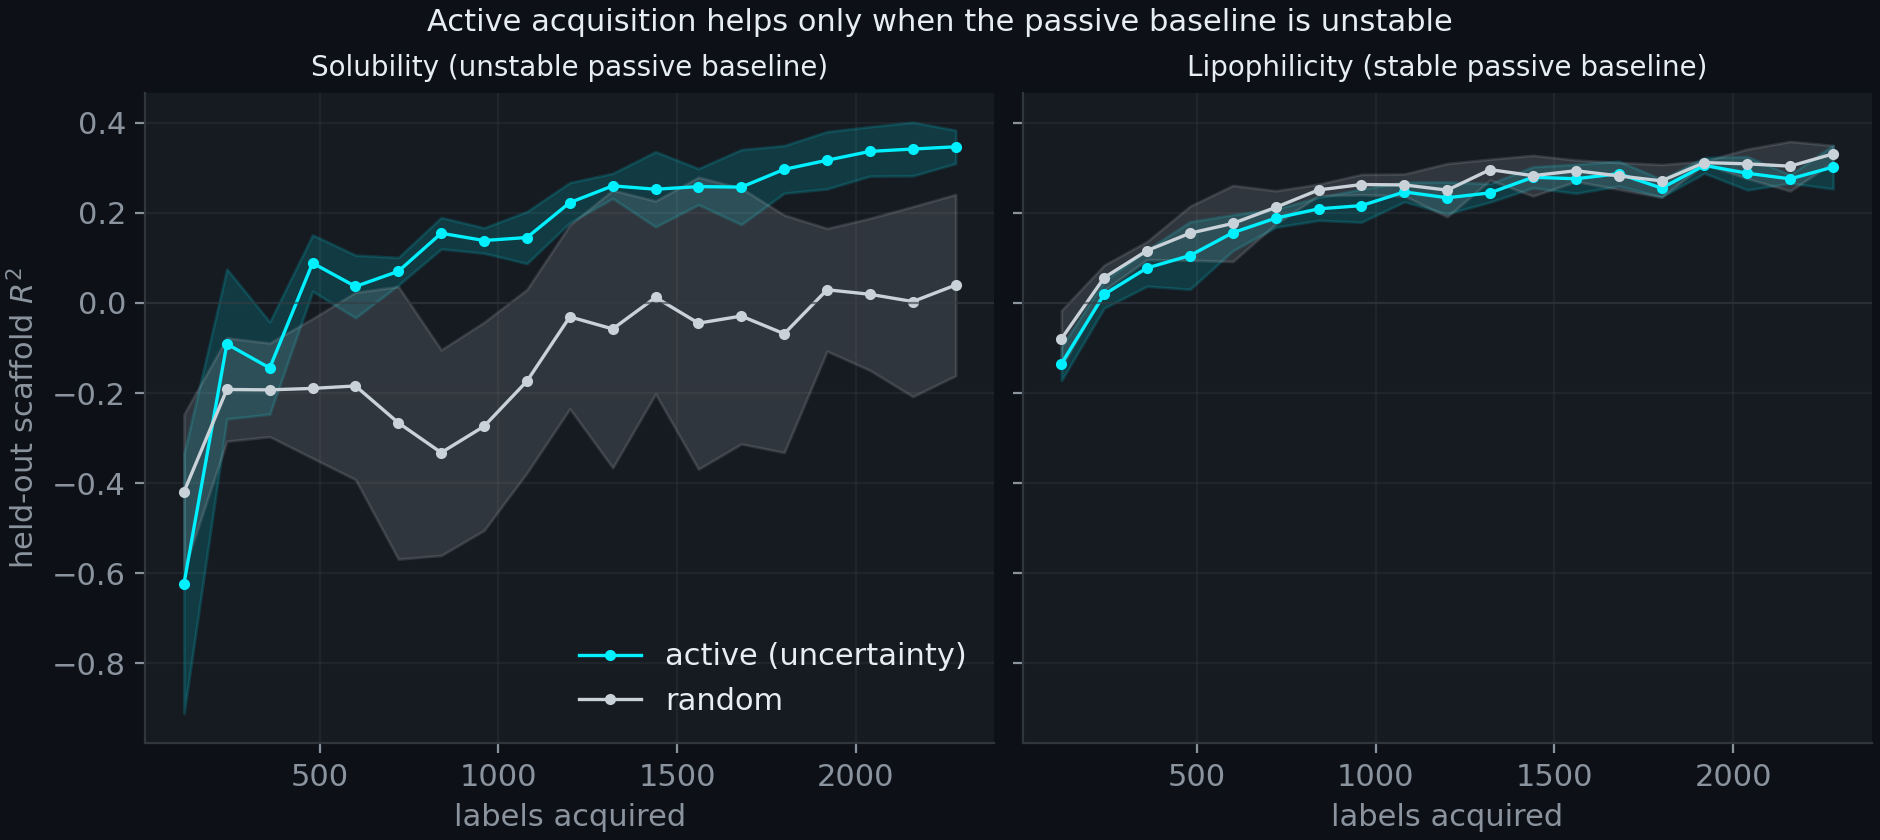

In [11]:
"""Show the committed regime-dependent label-efficiency figure (fig6)."""
show_fig("fig6_label_efficiency_regime.png")


## 4.6 End-to-end autonomous campaign

Finally we wire the pieces into one closed loop and let it run unattended over six ADMET
endpoints. For each endpoint the engine trains a calibrated oracle, poses an a-priori
go/no-go question, stops via SPRT, distills an abductive rule, and logs every step to a
DuckDB lineage store. The result is a campaign whose every decision is traceable from the
task all the way to the discovered rule.


E8 campaign: 6 GO / 0 NO-GO across 6 endpoints
measurements used 140 vs fixed 357  ->  61% saved

  bbb          GO (meaningful shift)      used  38 vs  68.7   rule = TPSA
  ames         GO (meaningful shift)      used  24 vs  68.7   rule = ArRings
  herg         GO (meaningful shift)      used  18 vs  49.0   rule = HeavyAtoms
  solubility   GO (meaningful shift)      used  10 vs  68.7   rule = MolLogP
  caco2        GO (meaningful shift)      used  17 vs  68.7   rule = HBD
  hia          GO (meaningful shift)      used  33 vs  33.0   rule = TPSA


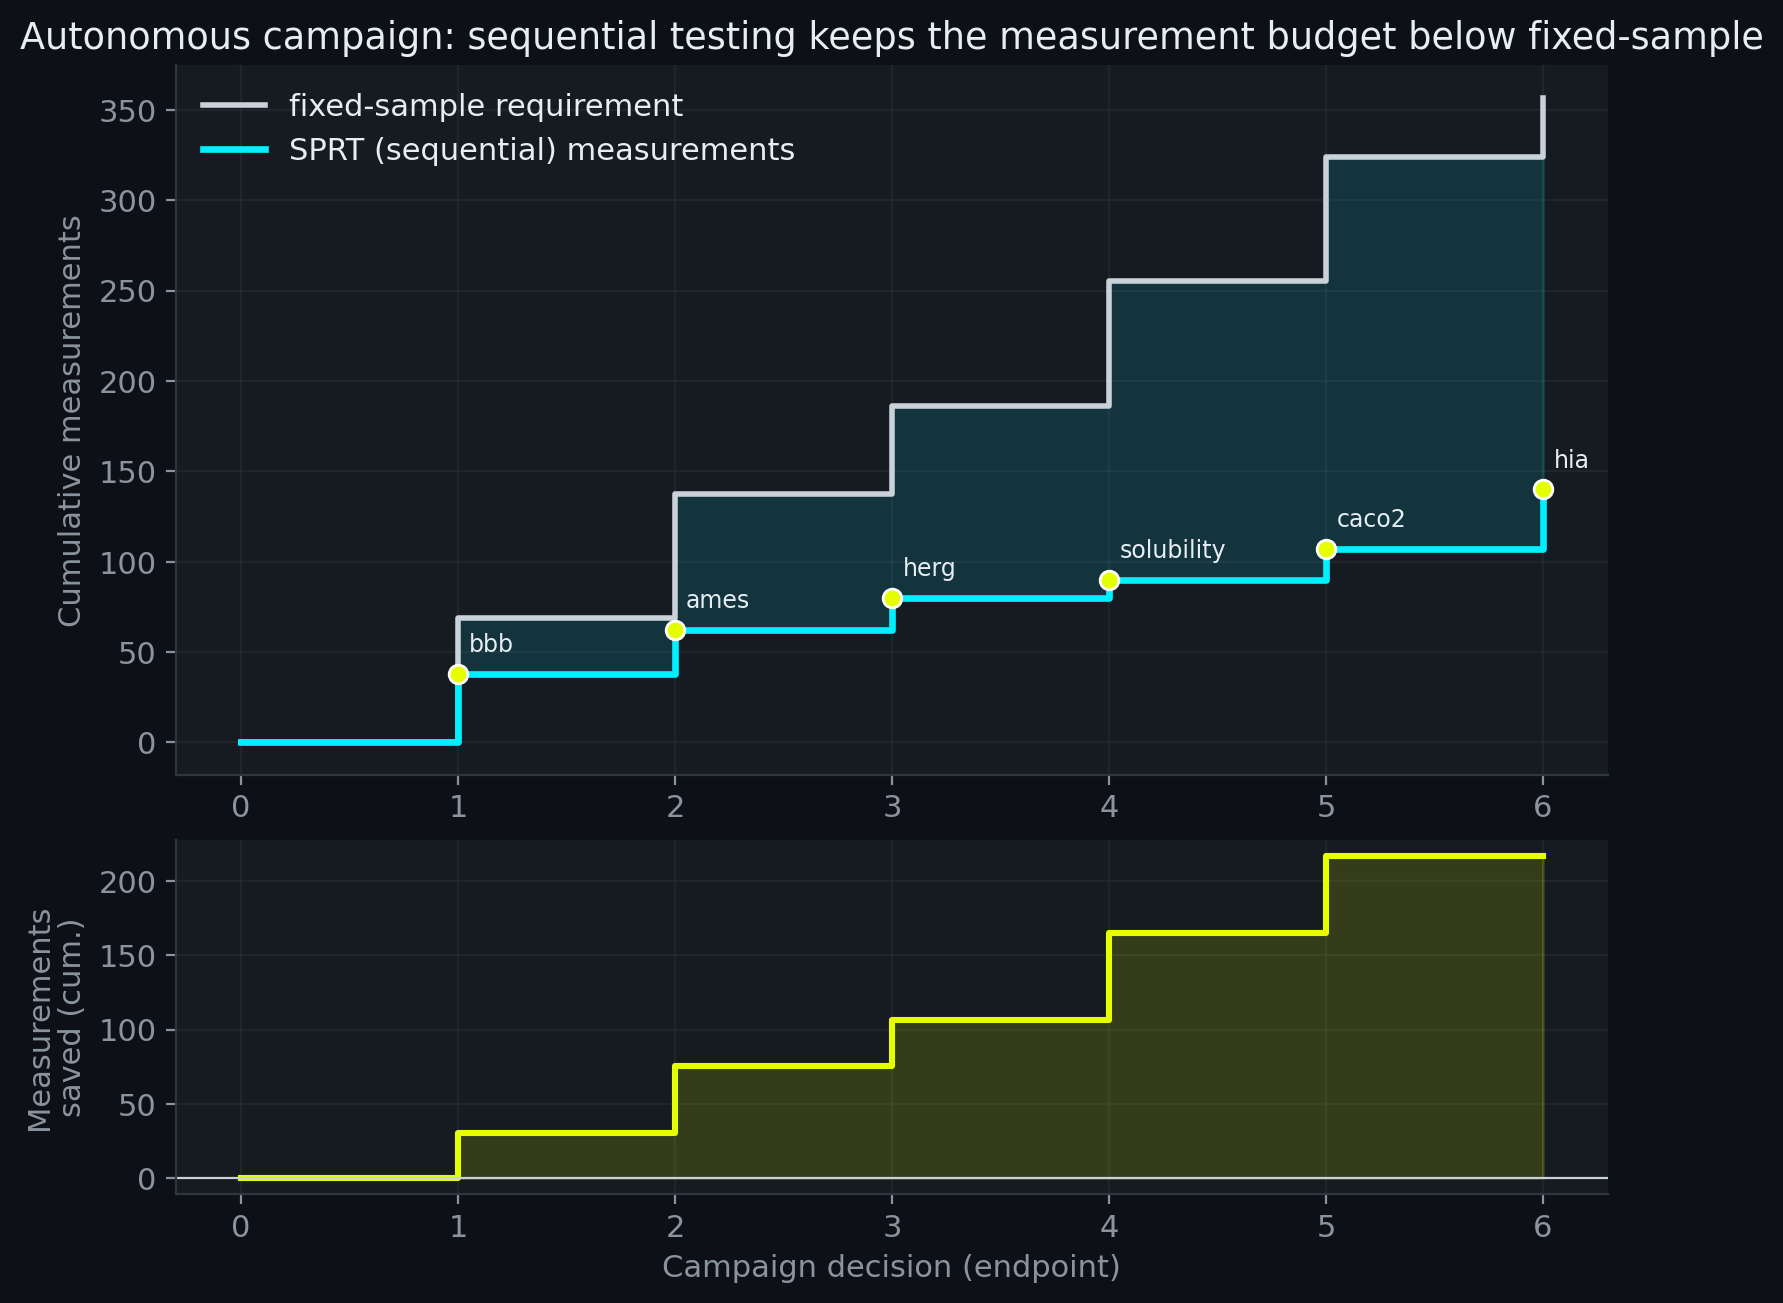

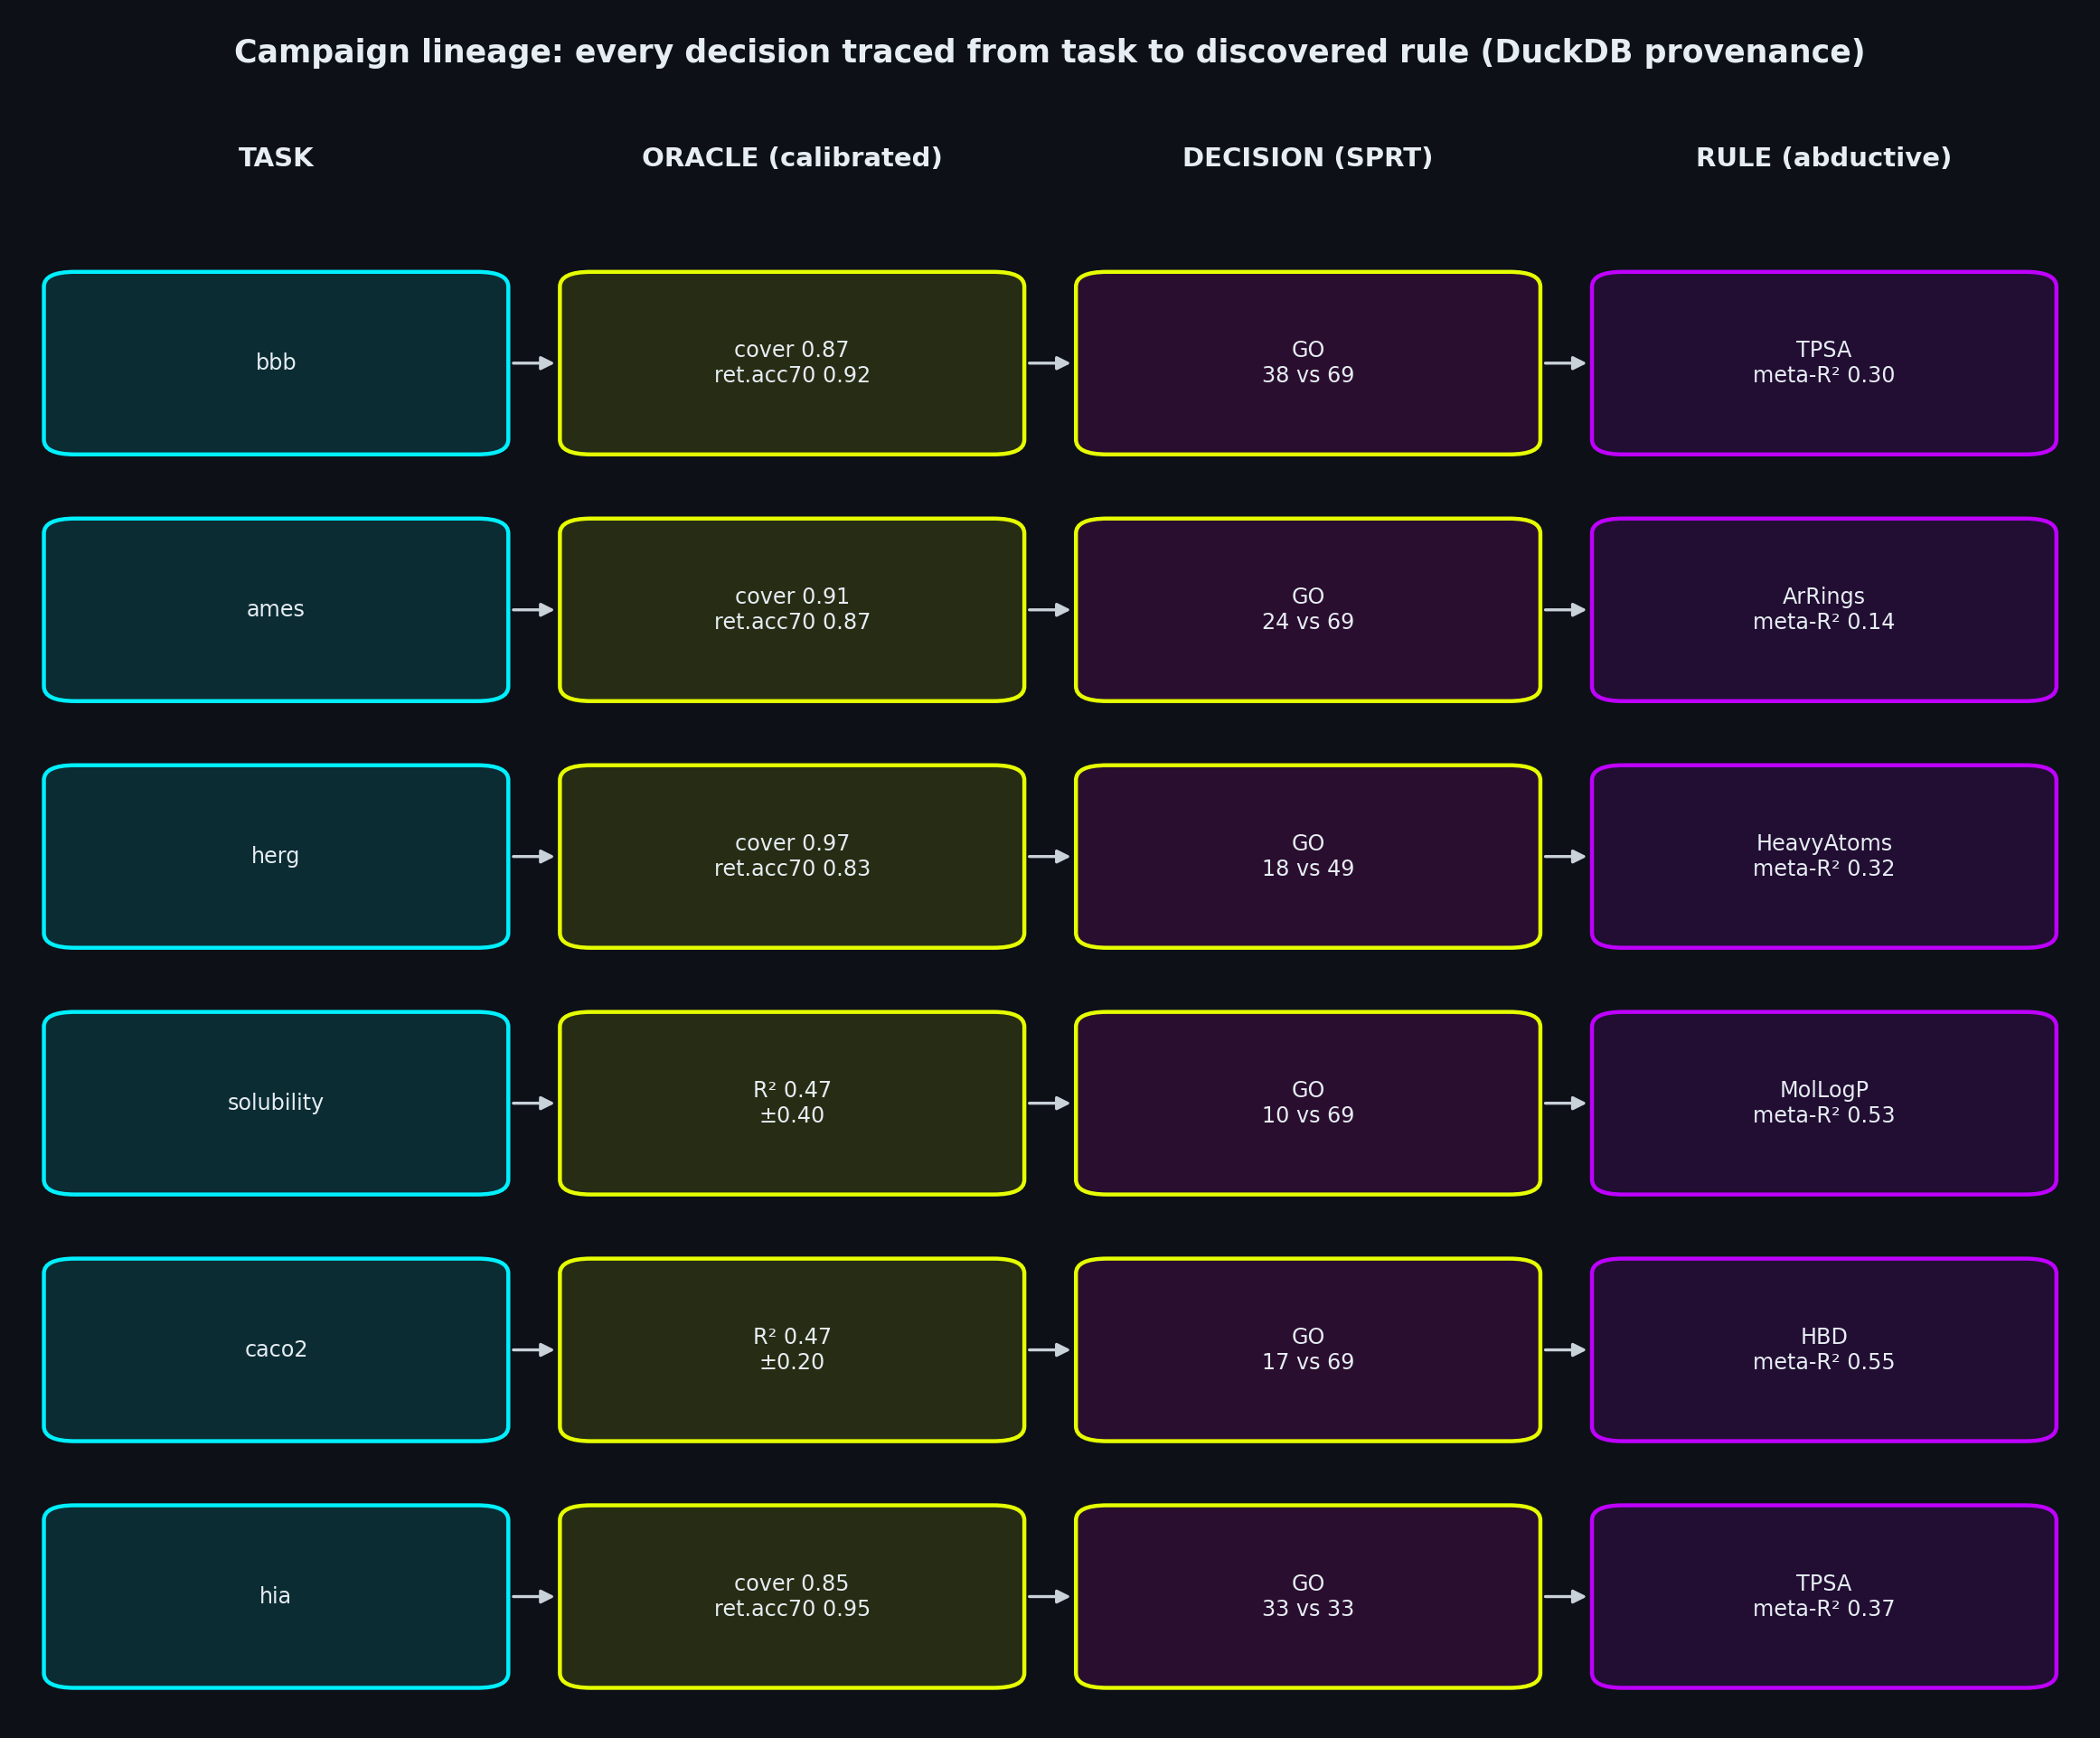

In [13]:
"""
Summarize the end-to-end autonomous campaign.

Intent: load the committed campaign roll-up and print, per endpoint, the SPRT
verdict, the measurements it used versus the fixed-sample requirement, and the
rule it distilled. The header line reports the campaign-wide budget saving; the
figures show the timeline and the task-to-rule lineage graph.
"""
camp = json.load(open(PRE / "e8_campaign_results.json"))
print(f"E8 campaign: {camp['decisions_go']} GO / {camp['decisions_nogo']} NO-GO "
      f"across {camp['n_endpoints']} endpoints")
print(f"measurements used {camp['total_measurements_used']} vs fixed "
      f"{camp['total_fixed_sample']:.0f}  ->  {camp['fraction_saved'] * 100:.0f}% saved\n")
for r in camp["records"]:
    s = r["sprt"]
    print(f"  {r['endpoint']:12s} {s['verdict']:26s} used {s['n_measurements']:3d} "
          f"vs {s['fixed_sample_n']:5.1f}   rule = {r['rule']['tree_feature']}")
show_fig("fig9_campaign_timeline.png", "fig10_lineage_graph.png")


## 5. Synopsis, and how to fully regenerate

Putting the four decisions together:

- **When to stop (SPRT).** Confident go/no-go calls using materially fewer measurements:
  61% fewer across the end-to-end campaign.
- **What you do not know (conformal).** Coverage holds at target even under scaffold
  shift, and **selective prediction** converts that calibrated uncertainty into a clean
  abstain rule that raises retained accuracy.
- **What you can read (abductive discovery).** Known drivers recovered on 5 of 5
  endpoints, plus a catalogue of activity cliffs.
- **Provenance.** Every decision is logged to DuckDB and can be replayed.

**CPU vs GPU.** Everything above runs on CPU. The only GPU work in the wider project was
the deep-ensemble acquisition study, which was refuted under hardening and survives only
as the pre-computed fig5 curves; no headline number depends on it.

Regenerate everything from the real Therapeutics Data Commons benchmarks:

```bash
make repro-spine       # calibration/SPRT spine + discovery + rule cards
make repro-campaign    # end-to-end autonomous campaign + timeline/lineage
```


#### Generative AI Disclosure

Some assertions and model development steps within this document were developed with
reference to Generative AI tools (Copilot; 2026 version). AI assistance was used for
clarifying concepts, validating code logic, identifying potential errors, and generating
some code segments. All AI-generated material was independently reviewed, debugged, and
validated for correctness before inclusion.


## References

1. Wald, A. (1945). Sequential tests of statistical hypotheses. *Annals of
   Mathematical Statistics*, 16(2), 117-186.
2. Chaloner, K. & Verdinelli, I. (1995). Bayesian experimental design: a review.
   *Statistical Science*, 10(3), 273-304.
3. Rainforth, T., Foster, A., Ivanova, D. R. & Bickford Smith, F. (2024). Modern
   Bayesian experimental design. *Statistical Science*, 39(1), 100-114.
4. Settles, B. (2012). *Active Learning*. Synthesis Lectures on AI and ML, Morgan &
   Claypool.
5. Vovk, V., Gammerman, A. & Shafer, G. (2005). *Algorithmic Learning in a Random
   World*. Springer.
6. Angelopoulos, A. N. & Bates, S. (2023). Conformal prediction: a gentle
   introduction. *Foundations and Trends in Machine Learning*, 16(4), 494-591.
7. Guo, C., Pleiss, G., Sun, Y. & Weinberger, K. Q. (2017). On calibration of modern
   neural networks. *ICML*.
8. Gal, Y. & Ghahramani, Z. (2016). Dropout as a Bayesian approximation:
   representing model uncertainty in deep learning. *ICML*.
9. Lakshminarayanan, B., Pritzel, A. & Blundell, C. (2017). Simple and scalable
   predictive uncertainty estimation using deep ensembles. *NeurIPS*.
10. El-Yaniv, R. & Wiener, Y. (2010). On the foundations of noise-free selective
    classification. *JMLR*, 11, 1605-1641.
11. Geifman, Y. & El-Yaniv, R. (2017). Selective classification for deep neural
    networks. *NeurIPS*.
12. Xu, K., Hu, W., Leskovec, J. & Jegelka, S. (2019). How powerful are graph neural
    networks? *ICLR*.
13. Velickovic, P., Cucurull, G., Casanova, A., Romero, A., Lio, P. & Bengio, Y.
    (2018). Graph attention networks. *ICLR*.
14. Huang, K., Fu, T., Gao, W., et al. (2021). Therapeutics Data Commons: machine
    learning datasets and tasks for drug discovery and development. *NeurIPS Datasets
    and Benchmarks*.
15. Bemis, G. W. & Murcko, M. A. (1996). The properties of known drugs. 1. Molecular
    frameworks. *Journal of Medicinal Chemistry*, 39(15), 2887-2893.
16. Guha, R. & Van Drie, J. H. (2008). Structure-activity landscape index: identifying
    and quantifying activity cliffs. *Journal of Chemical Information and Modeling*,
    48(3), 646-658.
17. Wald, A. & Wolfowitz, J. (1948). Optimum character of the sequential probability
    ratio test. *Annals of Mathematical Statistics*, 19(3), 326-339.
18. Tibshirani, R. J., Foygel Barber, R., Candès, E. & Ramdas, A. (2019). Conformal
    prediction under covariate shift. *NeurIPS*.
